### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [162]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [ ]:
Financial_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Financial Systems",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
Financial_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
14,7_0_0_0_0,https://economictimes.indiatimes.com/news/new-...,2023-10-31,"""AI zindabad"": Big B shares AI-created image, ...",74,"""AI zindabad"": Big B shares AI-created image, ..."
22,15_0_0_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",3,"""Bazaar"" surpasses ""Cathedral"", how does crypt..."


### Bertopic

In [ ]:
# ! pip install bertopic

In [8]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small")  # , device="cuda"

umap_model = UMAP(
    n_neighbors=50, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=20, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100, # smaller min_cluster_size will -> more detailed topics
    min_samples=50, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=8,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

In [9]:
docs = Financial_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [12]:
Financial_topics = topic_model.get_topic_info()
Financial_chunks_topics = Financial_chunks.assign( topic=topics,  probability=probs)

In [13]:
Financial_topics.to_csv(f"{DATA_DIR}/Industry_specific/Financial_topics.csv", index=False)
Financial_chunks_topics.to_parquet(f"{DATA_DIR}/Industry_specific/Financial_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [18]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [19]:
system_msg = """
You are an expert financial industry analyst and topic classification assistant.

Your task is to classify each BERTopic topic into EXACTLY ONE of the following 3 categories,
based on the combined evidence from:
1. topic keyword representation, and
2. representative documents.

### The 3 Categories

1. "AI_Financial_Impact"
Definition:
The topic is mainly about how AI, machine learning, generative AI, LLMs, algorithms,
predictive models, intelligent automation, or related AI systems are being applied in the financial industry,
or how they are changing financial workflows, decisions, services, operations, risk, compliance,
trading, underwriting, fraud detection, research, advisory, customer service, or other financial functions.

Examples include:
- AI in banking, insurance, capital markets, asset management, fintech, payments, lending
- AI improving or changing compliance, fraud detection, credit scoring, underwriting, KYC/AML
- AI for financial forecasting, portfolio analysis, trading, robo-advisory, operations, customer support
- discussions of AI adoption, implementation, use cases, workflow transformation, productivity, risk, or impact in finance

2. "AI_Related_Stock"
Definition:
The topic is mainly about stocks, share prices, valuation, market performance, analyst recommendations,
earnings, ETFs, tickers, investment commentary, or financial-market coverage of AI-related companies,
AI-themed funds, or AI-linked securities.

Examples include:
- stock performance of Nvidia, C3.ai, Palantir, Microsoft, Alphabet, etc.
- AI boom driving stock prices
- AI ETFs, AI investing themes, AI-related equity analysis
- buy/sell/hold recommendations, valuation, price targets, earnings discussions for AI-related firms

Important:
This category is about AI as an investment or stock-market subject,
NOT AI being applied inside financial-industry workflows.

3. "General_NonAI_Financial"
Definition:
The topic is mainly about general finance, banking, insurance, markets, regulation, lending,
consumer finance, macro-financial issues, accounting, real estate finance, or other financial-sector content,
but NOT mainly about AI applications/impact in finance and NOT mainly about AI-related stocks.

Examples include:
- interest rates, mortgages, bank regulation, consumer loans
- insurance operations not centered on AI
- accounting, tax, personal finance, corporate finance
- general market or financial news without AI as the core topic
- fintech or digital finance topics where AI is not the main subject

### Decision Rules

- Return EXACTLY ONE category.
- Use both Representation and Representative_Docs jointly.
- Focus on the MAIN topical center, not incidental mentions.
- A passing mention of AI is not enough for "AI_Financial_Impact".
- A passing mention of stocks is not enough for "AI_Related_Stock".
- If the topic is fundamentally about financial-industry use of AI, choose "AI_Financial_Impact".
- If the topic is fundamentally about AI-related companies/securities as investments, choose "AI_Related_Stock".
- Otherwise choose "General_NonAI_Financial".

### Boundary Clarification

Choose "AI_Financial_Impact" when:
- AI is being used BY financial institutions, financial professionals, or financial workflows
- the topic is about application, adoption, transformation, operational impact, or use case in finance

Choose "AI_Related_Stock" when:
- the topic is about AI companies or AI themes AS STOCKS / INVESTMENTS
- the core language is about shares, ticker, buy/sell, valuation, market cap, earnings, ETF, recommendation, performance

Choose "General_NonAI_Financial" when:
- the topic is financial, but AI is absent, marginal, or not the main topic
- the topic is not primarily about AI application in finance
- the topic is not primarily about AI-related securities or stock investing

### Boilerplate / Crawl Artifact Rule
Ignore non-substantive web residue such as:
- navigation/menu fragments
- privacy/cookie text
- subscription prompts
- duplicated headers/titles
- author/date/meta residue
- social sharing links
- unrelated mixed snippets
- ad blocks or UI/button fragments
- repeated site-wide template text

Do NOT use such content as topical evidence.

### Output Requirements
Return valid JSON only with the following fields:
- "category": one of the 3 category names exactly
- "relevant_keywords": a short list of the most informative keywords/phrases supporting the choice
- "reasoning": brief explanation of why the topic belongs to that category
- "reviewing": brief review of what the representative documents are mainly about and whether they support the classification

If evidence is weak or mixed, still choose the single best category conservatively.
"""

# =========================================================
# 2. User prompt template
# =========================================================
topic_classification_user_template = """
Here is one BERTopic topic from the financial domain.

Topic ID:
{Topic}

Topic Representation:
{Representation}

Representative documents:
{Representative_Docs}

Please classify this topic into exactly one of the 3 categories:
- AI_Financial_Impact
- AI_Related_Stock
- General_NonAI_Financial

Use the topic representation as the primary topic signal and use representative documents
to confirm the main semantic focus. Return JSON only.
"""

# =========================================================
# 3. JSON schema
# =========================================================
topic_classification_schema = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": [
                "AI_Financial_Impact",
                "AI_Related_Stock",
                "General_NonAI_Financial"
            ]
        },
        "relevant_keywords": {
            "type": "array",
            "items": {"type": "string"}
        },
        "reasoning": {
            "type": "string"
        },
        "reviewing": {
            "type": "string"
        }
    },
    "required": ["category", "relevant_keywords", "reasoning", "reviewing"],
    "additionalProperties": False
}


In [21]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

# =========================================================
# 5. Helper functions
# =========================================================
VALID_CATEGORIES = {
    "AI_Financial_Impact",
    "AI_Related_Stock",
    "General_NonAI_Financial"
}

def safe_str(x):
    if x is None:
        return ""
    return str(x)

def format_representation(x, max_chars=2500):
    text = safe_str(x).strip()
    if not text:
        return "[No topic representation provided]"
    return text[:max_chars]

def format_representative_docs(x, max_chars=12000):
    text = safe_str(x).strip()
    if not text:
        return "[No representative text provided]"
    return text[:max_chars]

def normalize_result(result):
    fallback = {
        "category": "General_NonAI_Financial",
        "relevant_keywords": [],
        "reasoning": "No clear evidence of AI-in-finance application or AI-related stock focus.",
        "reviewing": "Representative text is unclear, mixed, or not strongly informative."
    }

    if not isinstance(result, dict):
        return fallback

    category = result.get("category")
    relevant_keywords = result.get("relevant_keywords", [])
    reasoning = result.get("reasoning", "")
    reviewing = result.get("reviewing", "")

    if category not in VALID_CATEGORIES:
        return fallback

    if not isinstance(relevant_keywords, list):
        relevant_keywords = []

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    if not isinstance(reviewing, str) or not reviewing.strip():
        reviewing = fallback["reviewing"]

    normalized = {
        "category": category,
        "relevant_keywords": [str(k) for k in relevant_keywords],
        "reasoning": reasoning.strip(),
        "reviewing": reviewing.strip()
    }

    try:
        validate(instance=normalized, schema=topic_classification_schema)
        return normalized
    except ValidationError:
        return fallback

In [22]:
# 6. Batch run
# =========================================================
answers = []

for idx, row in Financial_topics.iterrows():
    user_msg = topic_classification_user_template.format(
        Topic=safe_str(row.get("Topic", "")),
        Representation=format_representation(row.get("Representation", ""), max_chars=2500),
        Representative_Docs=format_representative_docs(row.get("Representative_Docs", ""), max_chars=12000)
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)

        if "Insufficient Balance" in err_msg or "402" in err_msg:
            print(f"Stopped at row {idx}: insufficient API balance.")
            break

        result = {
            "category": None,
            "relevant_keywords": None,
            "reasoning": None,
            "reviewing": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    answers.append(result)

answers_df = pd.DataFrame(answers)

Financial_topics_out = pd.concat(
    [Financial_topics.iloc[:len(answers)].reset_index(drop=True),
     answers_df.reset_index(drop=True)],
    axis=1
)

Financial_topics_out.head()

,Topic,Count,Name,Representation,Representative_Docs,category,relevant_keywords,reasoning,reviewing,api_status
0,-1,824,-1_intelligence robotics_nasdaq artificial_tru...,"[intelligence robotics, nasdaq artificial, tru...",[First Trust Nasdaq Artificial Intelligence an...,AI_Related_Stock,[First Trust Nasdaq Artificial Intelligence an...,The topic focuses on an AI-themed ETF (First T...,The representative documents are primarily abo...,success
1,0,5474,0_compliance_financial institutions_processes_...,"[compliance, financial institutions, processes...",[Opportunities\n\nAdvanced Portfolio Optimizat...,AI_Financial_Impact,"[compliance, financial institutions, generativ...","The topic focuses on the application of AI, sp...",The representative documents discuss how gener...,success
2,1,5444,1_presale_xrp_decentralized_ethereum,"[presale, xrp, decentralized, ethereum, tokens...",[Stay tuned to his posts if you want to stay u...,General_NonAI_Financial,"[presale, xrp, decentralized, ethereum, tokens...",The topic representation and representative do...,The representative documents discuss cryptocur...,success
3,2,4714,2_advisor_indicator_forex_automated,"[advisor, indicator, forex, automated, timefra...",[(Note_SET FILE IS ATTACHED IN COMMENT)\nThe E...,AI_Financial_Impact,"[AI, automated, forex, trading, algorithm, pre...",The topic focuses on AI-powered automated trad...,The representative documents describe AI-drive...,success
4,3,3102,3_currencies_arabic_english_stocks currencies,"[currencies, arabic, english, stocks currencie...",[GET STARTEDMENAFN10042025003732001241ID110941...,General_NonAI_Financial,"[currencies, stocks currencies, mena, world mi...",The topic representation and representative do...,The representative documents are primarily web...,success


In [35]:
category_topics = Financial_topics_out.groupby('category')['Topic'].apply(list).to_dict()
print(category_topics)

df_ai_impact = Financial_chunks_topics[Financial_chunks_topics['topic'].isin(category_topics['AI_Financial_Impact'])]
df_ai_stock = Financial_chunks_topics[Financial_chunks_topics['topic'].isin(category_topics['AI_Related_Stock'])]

print(f"\n# of df_ai_impact chunks: {len(df_ai_impact)}")
print(f"# of df_ai_stock chunks: {len(df_ai_stock)}")

{'AI_Financial_Impact': [0, 2, 10], 'AI_Related_Stock': [-1, 4, 5, 7, 8, 9, 13, 14, 15, 18, 27, 28], 'General_NonAI_Financial': [1, 3, 6, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 29]}

# of df_ai_impact chunks: 10735
# of df_ai_stock chunks: 7708


In [38]:
df_ai_impact.to_parquet(f"{DATA_DIR}/Industry_specific/finance_df_ai_impact.parquet", index=False)
df_ai_stock.to_parquet(f"{DATA_DIR}/Industry_specific/finance_df_ai_stock.parquet", index=False)

### Sentiment Analysis on chunk level

#### AI Impact

##### 1. use LLM to generate 100 labels

In [37]:
df_ai_impact['topic'].value_counts()    

topic
0     5474
2     4714
10     547
Name: count, dtype: int64

In [82]:
import re
negative_keywords = ["risk","threat","displacement","pressure","regulatory","uncertainty","compliance issue","fraud","layoffs","cost pressure"]
pattern = r"\b(" + "|".join([re.escape(k) for k in negative_keywords]) + r")\b"

df_negative_candidates = df_ai_impact[
    df_ai_impact["chunk_text"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    )
][["chunk_uid", "topic", "chunk_text"]].sample(100, random_state=38).copy()
negative_candidate_uids = set(df_negative_candidates["chunk_uid"].tolist())

In [83]:
df_ai_impact_sample = pd.concat([
    df_ai_impact[df_ai_impact["topic"] == 0].sample(180, random_state=38),
    df_ai_impact[df_ai_impact["topic"] == 2].sample(170, random_state=38),
    df_ai_impact[df_ai_impact["topic"] == 10].sample(50, random_state=38),
])[["chunk_uid", "topic", "chunk_text"]].reset_index(drop=True)

stratified_uids = set(df_ai_impact_sample["chunk_uid"].tolist())

imbalanced_samples = ['688_0_0_0_1', '17078_0_0_0_1', '18374_0_0_0_1', '43564_3_0_0_1', '53743_0_0_0_0', '69043_0_0_0_0', '72764_0_1_3_2', '82394_0_0_0_0', '109416_0_0_0_2', '109439_1_0_0_0', '112079_0_0_0_0', '112422_3_0_0_0', '125558_0_0_0_0', '134609_0_0_0_0', '138913_1_0_0_2', '143750_0_0_0_2']
imbalanced_uids = set(imbalanced_samples)

combined_uids = stratified_uids.union(imbalanced_uids).union(negative_candidate_uids)
df_ai_impact_sample = df_ai_impact[df_ai_impact["chunk_uid"].isin(combined_uids)][["chunk_uid", "topic", "chunk_text"]].reset_index(drop=True)

In [84]:
system_msg = """
You are an expert financial industry analyst.

Your task is to evaluate how the industries and their companies described in the text
are expected to be impacted by AI or AI-related developments.

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
   The text suggests that AI or related technologies are expected to benefit the industry or companies.
   This includes improved efficiency, cost reduction, productivity gains, revenue growth,
   competitive advantage, innovation, expansion, or new opportunities.

2. "negatively"
   The text suggests that AI or related technologies are expected to harm or negatively impact the industry or companies.
   This includes job losses, competitive pressure, increased risks, market displacement,
   reduced margins, disruption, threats, or structural decline.

3. "hard-to-say"
   The text is neutral, mixed, uncertain, speculative, descriptive without clear direction,
   or presents both benefits and risks without a clear dominant direction.

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- If the text discusses both pros and cons without a clear dominant direction, choose "hard-to-say".
- If the text is mostly descriptive or factual without clear directional judgment, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""

impact_user_template = """
Here is a text segment from the financial domain:

{chunk_text}

Please determine whether the described industry or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [85]:
VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback
    

In [ ]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [93]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
positively     375
hard-to-say    113
negatively      18
Name: count, dtype: int64

['688_0_0_0_1', '13048_0_0_0_0', '17078_0_0_0_1', '18374_0_0_0_1', '43564_3_0_0_1', '53743_0_0_0_0', '69043_0_0_0_0', '72764_0_1_3_2', '74949_0_0_0_0', '82394_0_0_0_0', '109416_0_0_0_2', '109439_1_0_0_0', '112079_0_0_0_0', '112422_3_0_0_0', '125558_0_0_0_0', '134609_0_0_0_0', '138913_1_0_0_2', '143750_0_0_0_2']


lack negatively labeled samples, use llm api to generate some

In [105]:
style_prompts = [
    "Write in the style of a mainstream business newspaper: concise, factual, professional, and market-aware.",
    "Write in the style of a financial analysis outlet: more analytical, with emphasis on business implications, risk, and strategy.",
    "Write in the style of a technology-business news site: focus on product adoption, disruption, and operational consequences.",
    "Write in the style of a global economic newswire: neutral, information-dense, and report-like.",
    "Write in the style of an investigative financial publication: emphasize governance, regulatory concerns, and systemic risk.",
    "Write in the style of a professional industry trade publication for banking and finance: practical, sector-specific, and workflow-oriented.",
    "Write in the style of a policy and regulation news outlet: highlight compliance, oversight, legal exposure, and institutional response.",
    "Write in the style of a capital markets and investor media outlet: emphasize competitive pressure, valuation concerns, and firm-level consequences.",
    "Write in the style of a corporate risk and operations publication: focus on process failure, model risk, fraud exposure, and reputational damage.",
    "Write in the style of a long-form explanatory news site: accessible but serious, with clear causal explanation of negative effects."
]
import json
import pandas as pd
import openai
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

system_msg = """
You are a financial news writer.

Generate realistic news-style text passages about the negative impacts of AI on the financial industry.
Each passage should resemble a plausible article segment from a financial or business news source.

Requirements:
- Focus on negative impacts of AI in finance
- Topics may include layoffs, fraud, model risk, compliance failures, regulatory pressure,
  bias in lending or underwriting, cyber risk, reputational damage, operational errors,
  disruption to incumbents, margin pressure, surveillance concerns, market instability,
  or customer harm
- Use a neutral, journalistic tone
- Do not use bullet points
- Do not number items inside the text
- Each passage should be fully written prose, not a summary
- Each passage should be roughly 1200-1800 characters
- The 5 passages in one batch must differ clearly in structure and wording
- Use paragraph breaks with blank lines between paragraphs
- Return JSON only

Output format:
{
  "samples": [
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."}
  ]
}
"""

@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=1.1
    )
    return json.loads(completion.choices[0].message.content)

In [106]:
all_samples = []

for i, style in enumerate(style_prompts, start=1):
    user_msg = f"""
Generate 5 realistic news-style passages about the negative impact of AI on the financial industry and financial companies.

Style instruction:
{style}

Additional instructions:
- The five passages should not repeat each other
- They should vary in angle, such as banking, insurance, lending, compliance, fraud, operations, trading, or consumer finance
- Avoid copying common template phrasing
- Make the set feel like it came from different article excerpts rather than one repeated template
- Vary the paragraph structure noticeably across the 5 passages
- Some passages should be relatively compact with 2-3 paragraphs
- Some passages should be moderately developed with 4-5 paragraphs
- At least one passage should be more fully developed with 5-6 paragraphs
- Do not make all 5 passages appear as a single block of text
- Use blank lines between paragraphs
- Return JSON only
"""

    raw_result = get_answer(
        client=client,
        system_msg=system_msg,
        user_msg=user_msg,
        model="deepseek-chat"
    )

    batch_df = pd.DataFrame(raw_result["samples"]).copy()
    batch_df["style_prompt"] = style
    all_samples.append(batch_df)

In [107]:
df_synth_negative = pd.concat(all_samples, ignore_index=True)

df_synth_negative["impact_label"] = "negatively"
df_synth_negative["api_status"] = "synthetic_negative"
df_synth_negative["topic"] = -999
df_synth_negative["chunk_uid"] = [f"synth_neg_{i}" for i in range(len(df_synth_negative))]

df_synth_negative = df_synth_negative[
    ["chunk_uid", "topic","chunk_text", "impact_label",  "api_status"]
].reset_index(drop=True)

print(df_synth_negative.shape)
df_synth_negative.head()

(50, 5)


,chunk_uid,topic,chunk_text,impact_label,api_status
0,synth_neg_0,-999,Major investment banks are facing mounting pre...,negatively,synthetic_negative
1,synth_neg_1,-999,Insurance companies are confronting significan...,negatively,synthetic_negative
2,synth_neg_2,-999,Payment processors and digital banks are exper...,negatively,synthetic_negative
3,synth_neg_3,-999,Commercial lending institutions are grappling ...,negatively,synthetic_negative
4,synth_neg_4,-999,Asset management firms face growing concerns a...,negatively,synthetic_negative


In [110]:
df_synth_negative["n_char"] = df_synth_negative["chunk_text"].str.len()
display(df_synth_negative["n_char"].describe())

# show_full(df_synth_negative[[ "chunk_text"]].sample(10, random_state=42))

count      50.000000
mean     1577.500000
std       431.609624
min      1022.000000
25%      1223.750000
50%      1537.000000
75%      1728.250000
max      2883.000000
Name: n_char, dtype: float64

In [111]:
df_train_ai_impact_label_aug = pd.concat(
    [df_train_ai_impact_label, df_synth_negative],
    ignore_index=True
)

df_train_ai_impact_label_aug["impact_label"].value_counts()

impact_label
positively     375
hard-to-say    113
negatively      68
Name: count, dtype: int64

In [113]:
df_train_ai_impact_label_aug.to_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_impact_train_aug.parquet", index=False)

##### 2. finetune classifer

In [3]:
df_train_ai_impact_label_aug = pd.read_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_impact_train_aug.parquet")
df_train_ai_impact_label_aug.head()

,impact_label,reasoning,api_status,chunk_text,topic,chunk_uid,n_char
0,negatively,The text explicitly states that AI (specifical...,success,Agency and property disclosures are the two pr...,0,688_0_0_0_1,NaN
1,positively,The text describes algorithmic trading strateg...,success,The Neurolite EA will fine-tune all the parame...,2,1285_3_0_0_1,NaN
2,positively,The text describes multiple trading expert adv...,success,GoldPulser EA\n\nMohamed Hamdi Kaaniche\n\nGol...,2,1285_7_0_0_0,NaN
3,positively,The text describes using AI tools like ChatGPT...,success,The problem usually arises with not knowing wh...,0,3830_1_0_0_3,NaN
4,positively,The text explicitly describes AI as a tool tha...,success,9 Ways Agents Should Be Using AI To Drive Real...,0,4202_0_0_0_0,NaN


In [4]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label_aug.loc[df_train_ai_impact_label_aug["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,Agency and property disclosures are the two pr...,0
1,The Neurolite EA will fine-tune all the parame...,2
2,GoldPulser EA\n\nMohamed Hamdi Kaaniche\n\nGol...,2
3,The problem usually arises with not knowing wh...,2
4,9 Ways Agents Should Be Using AI To Drive Real...,2


In [5]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.15, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
2    318
1     96
0     58
Name: count, dtype: int64
label
2    57
1    17
0    10
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 472
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 84
    })
})

In [6]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/84 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 472
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 84
    })
})

In [8]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

model_dir = "/content/drive/MyDrive/NLP_project/models"
trained_model_name = "finance_ai_impact_classifier_v1"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [9]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.690773,0.678571,0.269504,0.226190,0.333333
2,0.759351,0.563341,0.773810,0.568581,0.549630,0.600000
3,0.759351,0.510462,0.797619,0.636866,0.850000,0.666701
4,0.513160,0.486415,0.821429,0.708995,0.876592,0.705917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/models/finance_ai_impact_classifier_v1/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/models/finance_ai_impact_classifier_v1/tokenizer.json')

In [10]:
eval_result = trainer.evaluate()
print(eval_result)

{'eval_loss': 0.4864145815372467, 'eval_accuracy': 0.8214285714285714, 'eval_macro_f1': 0.708994708994709, 'eval_macro_precision': 0.8765920070267897, 'eval_macro_recall': 0.7059167526659786, 'eval_runtime': 0.204, 'eval_samples_per_second': 411.727, 'eval_steps_per_second': 29.409, 'epoch': 4.0}


              precision    recall  f1-score   support

  negatively       0.82      0.90      0.86        10
 hard-to-say       1.00      0.24      0.38        17
  positively       0.81      0.98      0.89        57

    accuracy                           0.82        84
   macro avg       0.88      0.71      0.71        84
weighted avg       0.85      0.82      0.78        84



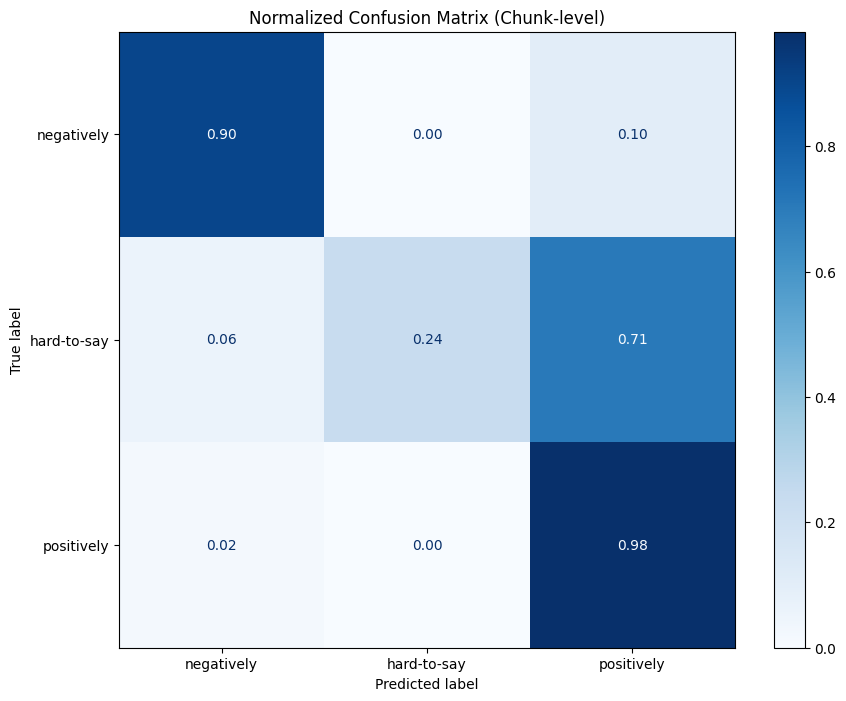

In [11]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [12]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Industry_specific/finance_df_ai_impact.parquet")
df_ai_impact.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,49_0_0_0_0,https://www.wbay.com/prnewswire/2022/02/03/cus...,2022-02-03,"""From customer service to complex banking task...",4,"""From customer service to complex banking task...",0,1.0
1,50_0_0_0_0,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",4,"""From customer service to complex banking task...",0,1.0
2,50_0_0_0_1,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",4,"Specifically, it is possible to guide how to u...",0,1.0
3,177_0_0_0_0,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",4,"""The REAL AI Guide for Real Estate Agents"" Hit...",0,1.0
4,177_0_0_0_1,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",4,Essential. Kevin brings the same clarity to AI...,0,1.0


In [15]:
print(df_ai_impact.shape)

(10735, 8)


In [21]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/10735 [00:00<?, ? examples/s]

In [22]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(10735, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,49_0_0_0_0,https://www.wbay.com/prnewswire/2022/02/03/cus...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",positively,0.903781,0.020864,0.075355,0.903781
1,50_0_0_0_0,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",positively,0.909130,0.021277,0.069593,0.909130
2,50_0_0_0_1,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",0,"Specifically, it is possible to guide how to u...",positively,0.834494,0.023489,0.142018,0.834494
3,177_0_0_0_0,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",0,"""The REAL AI Guide for Real Estate Agents"" Hit...",positively,0.845831,0.035950,0.118220,0.845831
4,177_0_0_0_1,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",0,Essential. Kevin brings the same clarity to AI...,positively,0.822126,0.036122,0.141752,0.822126


/tmp/ipykernel_2973/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


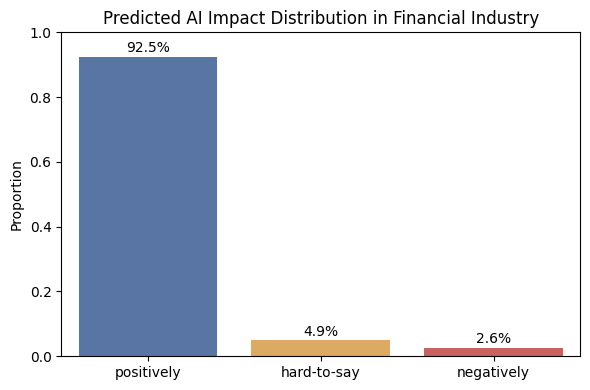

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
df_ai_impact_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

#### AI Stock

In [36]:
df_ai_stock = pd.read_parquet(f"{DATA_DIR}/Industry_specific/finance_df_ai_stock.parquet")

##### 1. use LLM to generate 100 labels

In [42]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [38]:
df_ai_stock_sample = df_ai_stock.sample(500, random_state=38)[["chunk_uid", "topic", "chunk_text"]].reset_index(drop=True)

In [ ]:
system_msg = """
You are a financial-text classification assistant.

Your task is to read a news text chunk and determine whether the text suggests that AI is likely to be favorable for stock performance ("good") or unfavorable / neutral / unclear ("bad-or-neutral") for the company, companies, or industry discussed.

Return JSON only with:
- stock_label: one of ["good", "bad-or-neutral"]
- reasoning: brief explanation grounded in the text

Labeling rules:
1. Use "good" only when the text contains reasonably clear evidence that AI could improve growth, profitability, competitiveness, efficiency, demand, market position, or investor outlook in a way that supports stock upside.
2. Use "bad-or-neutral" when:
   - the text suggests downside, risk, disruption, cost pressure, loss, uncertainty, regulatory concern, or competitive threat from AI
   - the text is merely descriptive or informational without clear stock-upside implication
   - the text is mixed or ambiguous
   - there is not enough evidence to support a "good" label
3. Be conservative. If the evidence for stock upside is not clear, choose "bad-or-neutral".
4. Do not add any text outside the JSON object.
""".strip()

stock_user_template = """
Classify the following news text chunk into one stock-impact label based on whether AI-related developments imply favorable stock outlook.

Return JSON only in this format:
{{
  "stock_label": "good" or "bad-or-neutral",
  "reasoning": "short explanation"
}}

News text:
\"\"\"
{chunk_text}
\"\"\"
""".strip()

stock_json_schema = {
    "type": "object",
    "properties": {
        "stock_label": {
            "type": "string",
            "enum": ["good", "bad-or-neutral"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["stock_label", "reasoning"],
    "additionalProperties": False
}

In [ ]:
VALID_STOCK_LABELS = {"good", "bad-or-neutral"}

def normalize_stock_result(result):
    fallback = {
        "stock_label": "bad-or-neutral",
        "reasoning": "Unclear, neutral, mixed, or insufficient evidence for AI-driven stock upside."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("stock_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_STOCK_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "stock_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=stock_json_schema)
        return normalized
    except ValidationError:
        return fallback

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [43]:
train_ai_stock_label = []

df_ai_stock_sample_50 = df_ai_stock_sample.sample(50, random_state=38).reset_index(drop=True)
for idx, row in df_ai_stock_sample.iterrows():

    text = row["chunk_text"]

    user_msg = stock_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_stock_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "stock_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result["chunk_uid"] = row["chunk_uid"]

    train_ai_stock_label.append(result)

In [44]:
df_train_ai_stock_label = pd.DataFrame(train_ai_stock_label)
display(df_train_ai_stock_label['stock_label'].value_counts())

,count
stock_label,
bad-or-neutral,342
good,158


In [49]:
df_train_ai_stock_label.to_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_stock_train.parquet", index=False)

##### 2. finetune classifer

In [50]:
df_train_ai_stock_label = pd.read_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_stock_train.parquet")
df_train_ai_stock_label.head()

,stock_label,reasoning,api_status,chunk_text,topic,chunk_uid
0,good,The text highlights AI developments for Amplit...,success,Let's take a look at two of them worth buying ...,4,1977_0_0_0_1
1,good,The text highlights Nvidia's strong AI demand ...,success,Nvidia earnings to offer first true glimpse of...,4,95313_0_0_0_0
2,bad-or-neutral,The text mentions concerns about AI risks such...,success,But he also noted the need to address concerns...,14,118288_0_0_0_1
3,good,The text highlights Nvidia's strong revenue fo...,success,Its forecast of roughly $11 billion in revenue...,8,120371_0_0_0_1
4,bad-or-neutral,The text provides financial comparisons for SE...,success,"Comparatively, 42.1% of shares of all “Miscell...",9,110464_0_0_0_1


In [51]:
label2id = {
    "bad-or-neutral": 0,
    "good": 1
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_stock_label.loc[df_train_ai_stock_label["stock_label"].isin(label2id.keys()), ["chunk_text", "stock_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["stock_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,Let's take a look at two of them worth buying ...,1
1,Nvidia earnings to offer first true glimpse of...,1
2,But he also noted the need to address concerns...,0
3,Its forecast of roughly $11 billion in revenue...,1
4,"Comparatively, 42.1% of shares of all “Miscell...",0


In [52]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.15, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
0    291
1    134
Name: count, dtype: int64
label
0    51
1    24
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 425
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 75
    })
})

In [58]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/425 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 425
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 75
    })
})

In [ ]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

model_dir = "/content/drive/MyDrive/NLP_project/models"
trained_model_name = "finance_ai_stock_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [60]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.529090,0.720000,0.573055,0.717437,0.584559
2,0.524103,0.448171,0.733333,0.669312,0.691520,0.660539
3,0.524103,0.485131,0.760000,0.747001,0.745337,0.779412
4,0.352408,0.465916,0.746667,0.717766,0.712963,0.725490
5,0.352408,0.464913,0.746667,0.717766,0.712963,0.725490


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/models/finance_ai_stock_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/models/finance_ai_stock_classifier/tokenizer.json')

                precision    recall  f1-score   support

bad-or-neutral       0.90      0.73      0.80        51
          good       0.59      0.83      0.69        24

      accuracy                           0.76        75
     macro avg       0.75      0.78      0.75        75
  weighted avg       0.80      0.76      0.77        75



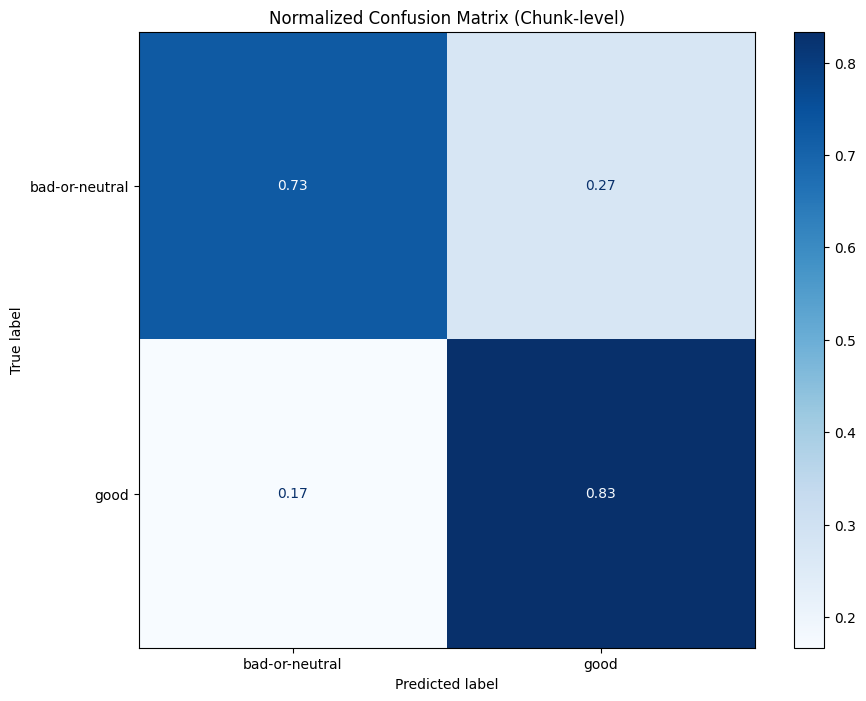

In [61]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [62]:
print(df_ai_stock.shape)

(7708, 8)


In [64]:
from datasets import Dataset

df_ai_stock_pred = (
    df_ai_stock[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

ai_stock_pred_dataset = Dataset.from_pandas(df_ai_stock_pred, preserve_index=False)
ai_stock_pred_dataset = ai_stock_pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/7708 [00:00<?, ? examples/s]

In [65]:
pred_output = trainer.predict(ai_stock_pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_stock_pred["pred_label_id"] = pred_ids
df_ai_stock_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_stock_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_stock_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_stock_pred.shape)
df_ai_stock_pred.head()

(7708, 10)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_bad-or-neutral,prob_good
0,250_1_0_0_0,https://finance.yahoo.com/news/ddamanda-softwa...,2022-12-30,#DDAmanda Software Finds Winning Stocks using ...,15,Recommended StoriesMotley Fool3 Top Stocks Wor...,bad-or-neutral,0.842604,0.842604,0.157396
1,250_1_0_1_0,https://finance.yahoo.com/news/ddamanda-softwa...,2022-12-30,#DDAmanda Software Finds Winning Stocks using ...,15,Here Are the Hours for the New Year’s Weekend....,bad-or-neutral,0.921145,0.921145,0.078855
2,334_0_0_0_0,https://www.benzinga.com/markets/tech/25/07/46...,2025-07-22,$500 Billion Stumble: SoftBank–OpenAI's Massiv...,14,$500 Billion Stumble: SoftBank–OpenAI's Massiv...,bad-or-neutral,0.732400,0.732400,0.267600
3,334_0_0_0_1,https://www.benzinga.com/markets/tech/25/07/46...,2025-07-22,$500 Billion Stumble: SoftBank–OpenAI's Massiv...,14,Although both companies committed billions and...,bad-or-neutral,0.563558,0.563558,0.436442
4,341_0_0_0_0,https://www.nasdaq.com/articles/7-trillion-lin...,2025-05-08,$7 Trillion on the Line: How AI Stocks Could F...,-1,$7 Trillion on the Line: How AI Stocks Could F...,good,0.645623,0.354377,0.645623


/tmp/ipykernel_2973/2667917361.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2973/2667917361.py:8: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(


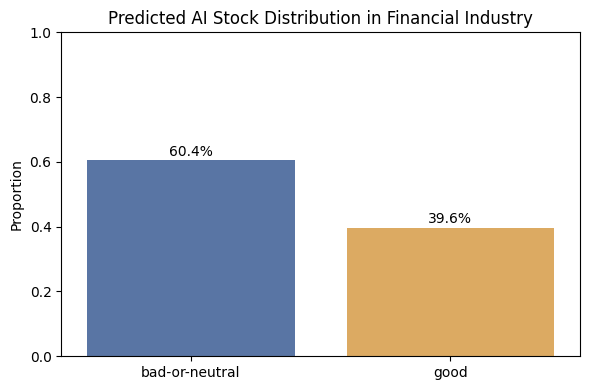

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

dist = df_ai_stock_pred["pred_label"].value_counts(normalize=True)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Stock Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [68]:
df_ai_stock_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [17]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/finance_ai_impact_classifier_v1_predictions.parquet")
df_ai_impact_pred.head(2)

,chunk_uid,url,date,title,topic,text,pred_label_id,pred_label,prob_negatively,prob_hard-to-say,prob_positively
0,49_0_0_0_0,https://www.wbay.com/prnewswire/2022/02/03/cus...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",2,positively,0.020864,0.075355,0.903781
1,50_0_0_0_0,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",2,positively,0.021277,0.069593,0.909130


#### Positive impact

In [18]:
df_ai_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(1000, random_state=38).reset_index(drop=True)

In [19]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [20]:
entity_system_msg = """\
You are an information extraction system for finance-related news articles.

The user will provide a text block from a finance-related article.
Your task is to extract only the following:

1. organizations or companies in the finance ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named companies, banks, fintech firms or other finance-related institutions explicitly stated in the text.

Examples:
- JPMorgan Chase
- Goldman Sachs
- Morgan Stanley
- BlackRock
- PayPal
- Stripe
- Nasdaq
- SEC

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies or business impact mechanisms explicitly mentioned in the text.

This includes but not limited to:
- automation
- augmentation
- workflow redesign
- cost reduction
- productivity improvement
- generative AI
- large language models
- machine learning
- predictive analytics
- fraud detection
- risk modeling
- document processing
- underwriting automation
- chatbots
- algorithmic trading support
- compliance monitoring
- back-office automation

## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the bank”, “the company”, “financial institutions”, unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [21]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [22]:
train_ai_impact_ner = []

for idx, row in df_ai_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_impact_ner.append(result)
    
df_ai_impact_ner_result = pd.DataFrame(train_ai_impact_ner)

In [31]:
df_ai_impact_ner_result.to_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_impact_ner.parquet", index=False)

##### Organization 

In [70]:
df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_impact_ner.parquet")

In [76]:
df_posorg_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(1273, 2)
(214, 2)


,entity_raw,raw_count
0,MetaTrader 5,27
1,OpenAI,25
2,Microsoft,21
3,Google,19
4,Nasdaq,17
...,...,...
209,ICICI Bank,2
210,ATTOM,2
211,Anthropic,2
212,Forbes,2


In [82]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

"- (MetaTrader 5, 27)\n- (OpenAI, 25)\n- (Microsoft, 21)\n- (Google, 19)\n- (Nasdaq, 17)\n- (MetaTrader 4, 16)\n- (MQL5, 14)\n- (Quantum AI, 11)\n- (IBM, 10)\n- (Gray Media Group, 10)\n- (Zest AI, 9)\n- (GlobalData, 9)\n- (Amazon, 9)\n- (FCA, 9)\n- (Mastercard, 9)\n- (Visa, 8)\n- (JPMorgan Chase, 8)\n- (Gartner, 7)\n- (AWS, 7)\n- (JPMorgan, 7)\n- (PRNewswire, 7)\n- (IC Markets, 7)\n- (ICMarkets, 7)\n- (Zillow, 7)\n- (Intuit, 7)\n- (Salesforce, 6)\n- (EIN Presswire, 6)\n- (Resistant AI, 6)\n- (NVIDIA, 5)\n- (NASDAQ, 5)\n- (MQL5.com, 5)\n- (Bank of America, 5)\n- (Oracle, 5)\n- (Nvidia, 5)\n- (Goldman Sachs, 5)\n- (EY, 5)\n- (Citi, 5)\n- (McKinsey, 5)\n- (Apple, 5)\n- (Wells Fargo, 4)\n- (BNP Paribas, 4)\n- (Equifax, 4)\n- (HSBC, 4)\n- (Meta, 4)\n- (Stripe, 4)\n- (Kaizen AI, 4)\n- (Morgan Stanley, 4)\n- (PYMNTS, 4)\n- (Profalgo Limited, 4)\n- (QuickBooks, 4)\n- (UBS, 4)\n- (United-CFX, 4)\n- (VentureBeat, 4)\n- (Walmart, 4)\n- (IDC, 3)\n- (Binance, 3)\n- (JP Morgan, 3)\n- (Amazon Web Ser

In [83]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from finance-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - finance_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 finance companies
   - Top 10 AI companies

Rules:
- Be conservative when merging.
- Do not merge different companies.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "finance_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "finance_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["finance_top10", "ai_top10"],
    "additionalProperties": False
}

In [84]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [151]:
industry_company_top10_pos = pd.DataFrame(result_posorg["finance_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Finance Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Finance Top 10


,canonical_name,total_count,source_raw_names
0,JPMorgan Chase,18,"[JPMorgan Chase, JPMorgan, JP Morgan]"
1,Mastercard,9,[Mastercard]
2,Visa,8,[Visa]
3,Bank of America,5,[Bank of America]
4,Goldman Sachs,5,[Goldman Sachs]
5,Citi,5,[Citi]
6,Wells Fargo,4,[Wells Fargo]
7,BNP Paribas,4,[BNP Paribas]
8,HSBC,4,[HSBC]
9,Morgan Stanley,4,[Morgan Stanley]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,25,[OpenAI]
1,Google,24,"[Google, Google Cloud, Google LLC]"
2,Microsoft,21,[Microsoft]
3,Amazon,12,"[Amazon, AWS, Amazon Web Services]"
4,NVIDIA,10,"[NVIDIA, Nvidia]"
5,IBM,12,"[IBM, IBM Corporation]"
6,Salesforce,8,"[Salesforce, Salesforce, Inc.]"
7,Apple,5,[Apple]
8,Oracle,5,[Oracle]
9,Meta,6,"[Meta, Facebook]"


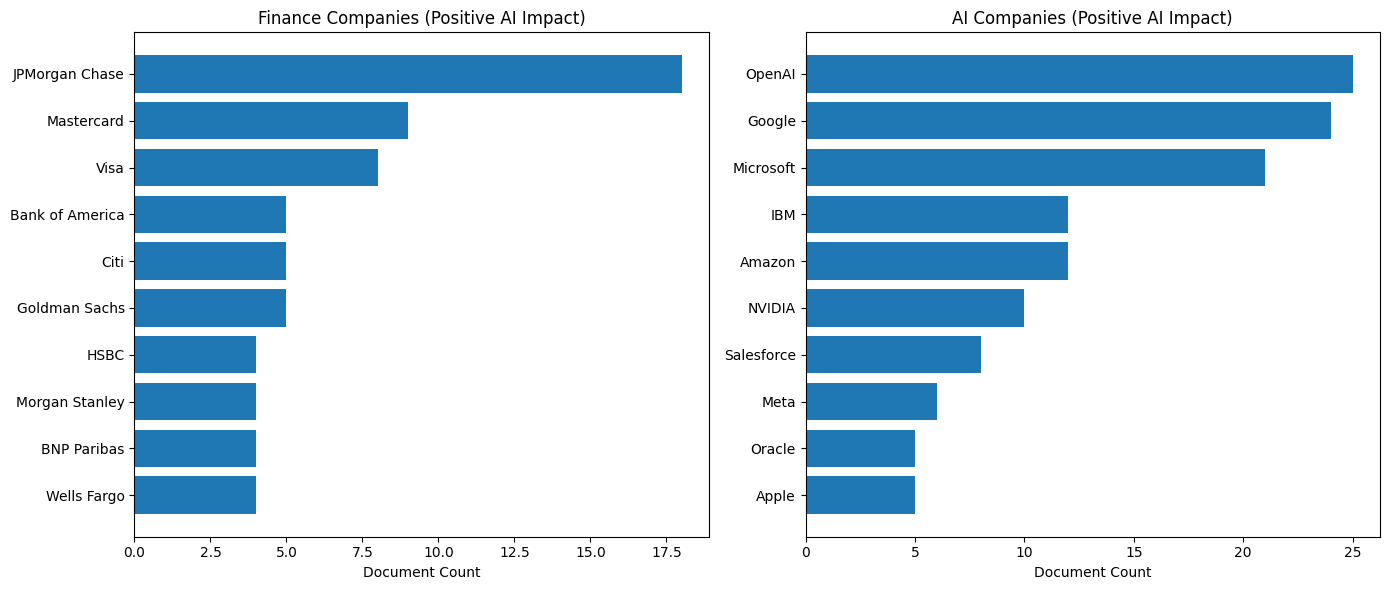

In [152]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [86]:
df_posmech_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(2129, 2)
(295, 2)


,entity_raw,raw_count
0,automation,130
1,machine learning,120
2,generative AI,99
3,artificial intelligence,98
4,AI,87
...,...,...
290,workflow,2
291,artificial intelligence algorithms,2
292,глубоких нейронных сетей,2
293,машинного обучения,2


In [87]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (automation, 130)\n- (machine learning, 120)\n- (generative AI, 99)\n- (artificial intelligence, 98)\n- (AI, 87)\n- (fraud detection, 81)\n- (productivity improvement, 48)\n- (chatbots, 41)\n- (cost reduction, 41)\n- (ChatGPT, 35)\n- (predictive analytics, 35)\n- (workflow redesign, 28)\n- (large language models, 27)\n- (algorithmic trading support, 24)\n- (compliance monitoring, 23)\n- (Artificial Intelligence, 22)\n- (automated trading, 22)\n- (document processing, 22)\n- (risk modeling, 21)\n- (augmentation, 19)\n- (back-office automation, 17)\n- (fraud prevention, 16)\n- (natural language processing, 16)\n- (underwriting automation, 14)\n- (algorithms, 14)\n- (risk management, 14)\n- (underwriting, 13)\n- (AI agents, 12)\n- (neural network, 12)\n- (data analytics, 12)\n- (AI technology, 12)\n- (automated trading system, 11)\n- (risk assessment, 11)\n- (algorithm, 11)\n- (efficiency, 11)\n- (AI tools, 9)\n- (deep learning, 9)\n- (neural networks, 9)\n- (Expert Advisor, 9)\n- (alg

In [88]:
posmech_top_system_msg = """\
You are an AI technology and business mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from finance-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_business_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI business mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.
Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing

### ai_business_mechanism
Business applications, operational impacts, or use-case mechanisms of AI.
Examples:
- automation
- cost reduction
- productivity improvement
- workflow redesign
- fraud detection
- underwriting automation
- document processing
- compliance monitoring
- algorithmic trading support

### other
Anything vague, unclear, or not clearly technology or mechanism.

Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [89]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [156]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,artificial intelligence,213,"[artificial intelligence, AI, Artificial Intel..."
1,machine learning,146,"[machine learning, Machine Learning, ML, machi..."
2,generative AI,122,"[generative AI, Generative AI, GenAI, gen AI, ..."
3,large language models,37,"[large language models, LLMs, LLM, large langu..."
4,neural networks,32,"[neural network, neural networks, Neural Netwo..."
5,natural language processing,28,"[natural language processing, Natural Language..."
6,deep learning,20,"[deep learning, deep-learning, deep learning a..."
7,predictive analytics,35,[predictive analytics]
8,algorithms,36,"[algorithms, algorithm, advanced algorithms, m..."
9,computer vision,4,"[computer vision, Computer Vision]"


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,automation,217,"[automation, back-office automation, automated..."
1,fraud detection,103,"[fraud detection, fraud prevention, anti-money..."
2,cost reduction,49,"[cost reduction, cost savings, reduce costs, r..."
3,productivity improvement,55,"[productivity improvement, productivity gains,..."
4,algorithmic trading support,37,"[algorithmic trading support, algorithmic trad..."
5,chatbots,57,"[chatbots, chatbot, AI chatbot, AI-powered cha..."
6,compliance monitoring,36,"[compliance monitoring, compliance, regulatory..."
7,document processing,24,"[document processing, automated document proce..."
8,underwriting automation,32,"[underwriting automation, underwriting, automa..."
9,risk management,39,"[risk modeling, risk management, risk assessme..."


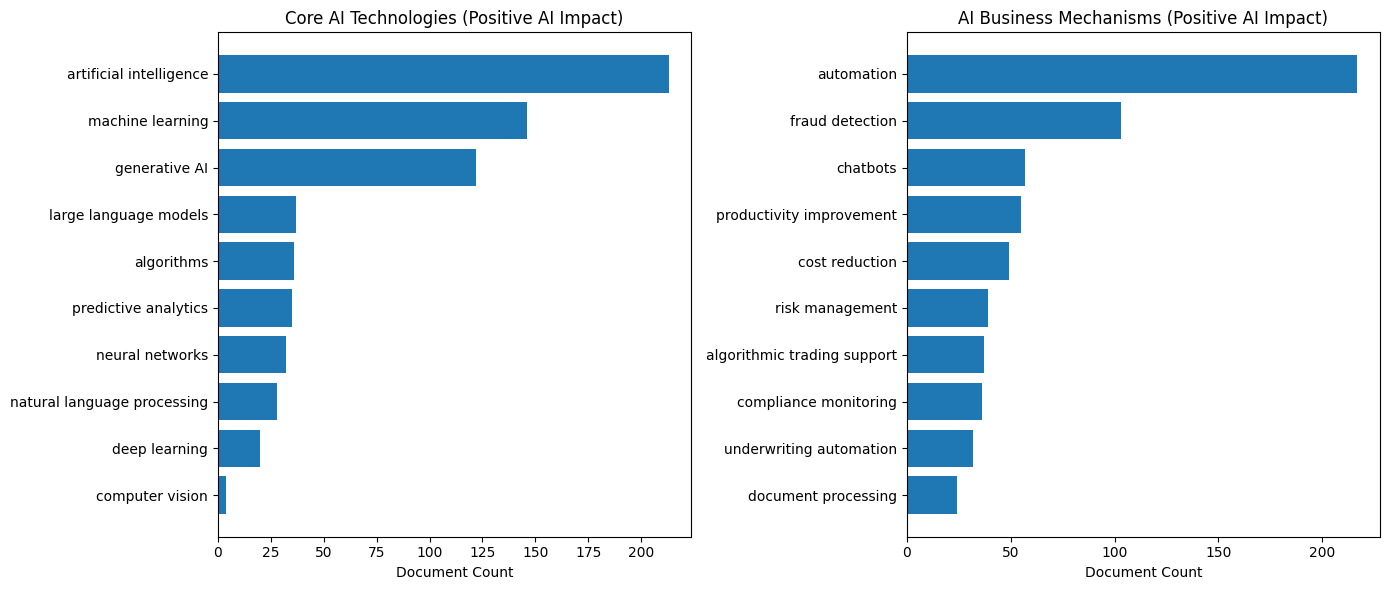

In [157]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [55]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

284


In [ ]:
neg_entity_system_msg = """\
You are an information extraction system for finance-related news articles.

The user will provide a text block from a finance-related article.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or companies in the finance ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named companies, banks, fintech firms, regulators, exchanges, or other finance-related institutions explicitly stated in the text.

Examples:
- JPMorgan Chase
- Goldman Sachs
- Morgan Stanley
- BlackRock
- PayPal
- Stripe
- Nasdaq
- SEC

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:
- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related negative business, operational, regulatory, ethical, or financial impact mechanisms explicitly mentioned in the text

Examples of technologies / capabilities:
- generative AI
- large language models
- machine learning
- predictive analytics
- chatbots
- document processing
- risk modeling

Examples of NEGATIVE impact mechanisms:
- job displacement
- workforce reduction
- layoffs
- risk of using AI-generated content
- privacy concerns
- data leakage
- implementation cost
- system failure
- inaccurate decision-making
- overreliance on AI
- litigation risk
- market manipulation risk
- loss of trust
- margin pressure

## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the bank”, “the company”, “financial institutions”, unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [ ]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

In [58]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Industry_specific/finance_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [91]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(383, 2)
(121, 2)


,entity_raw,raw_count
0,SEC,25
1,OpenAI,21
2,IRS,16
3,Federal Reserve,13
4,Greystar,11
...,...,...
116,TaxBuddy,2
117,Apple,2
118,Transparently.ai,2
119,VentureBeat,2


In [94]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

'- (SEC, 25)\n- (OpenAI, 21)\n- (IRS, 16)\n- (Federal Reserve, 13)\n- (Greystar, 11)\n- (White House, 11)\n- (RealPage, 11)\n- (Real Page, 10)\n- (Securities and Exchange Commission, 9)\n- (Google, 9)\n- (European Union, 8)\n- (Financial Stability Oversight Council, 8)\n- (FICO, 7)\n- (IBM, 7)\n- (Unity Software Inc, 7)\n- (CFPB, 7)\n- (AvalonBay, 6)\n- (Goldman Sachs, 6)\n- (HSBC, 6)\n- (Microsoft, 5)\n- (Nasdaq, 5)\n- (Zillow Group Inc, 5)\n- (Treasury, 5)\n- (San Francisco, 5)\n- (Justice Department, 5)\n- (Internal Revenue Service, 5)\n- (Klarna, 5)\n- (Financial Times, 5)\n- (FTC, 5)\n- (Federal Trade Commission, 5)\n- (Consumer Financial Protection Bureau, 5)\n- (Amazon, 5)\n- (U.S. Securities and Exchange Commission, 4)\n- (Bank of America, 4)\n- (CFTC, 4)\n- (Jersey City’s Municipal Council, 4)\n- (JPMorgan Chase, 4)\n- (Morgan Stanley, 4)\n- (McKinsey & Co, 4)\n- (Massachusetts Institute of Technology, 4)\n- (OCC, 4)\n- (H&R Block, 4)\n- (Government Accountability Office, 4)\n

In [95]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [153]:
industry_company_top10_neg = pd.DataFrame(result_negorg["finance_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Finance Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Finance Top 10


,canonical_name,total_count,source_raw_names
0,Securities and Exchange Commission,40,"[SEC, Securities and Exchange Commission, U.S...."
1,Internal Revenue Service,21,"[IRS, Internal Revenue Service]"
2,Federal Reserve,13,[Federal Reserve]
3,Consumer Financial Protection Bureau,12,"[CFPB, Consumer Financial Protection Bureau]"
4,RealPage,11,"[RealPage, Real Page]"
5,Financial Stability Oversight Council,8,[Financial Stability Oversight Council]
6,FICO,7,"[FICO, Fair Isaac Corp]"
7,Goldman Sachs,6,[Goldman Sachs]
8,HSBC,6,[HSBC]
9,JPMorgan Chase,7,"[JPMorgan Chase, JPMorgan]"


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,21,[OpenAI]
1,Google,9,[Google]
2,IBM,7,[IBM]
3,Microsoft,5,[Microsoft]
4,Amazon,5,"[Amazon, Amazon Web Services]"
5,Anthropic,3,[Anthropic]
6,Nvidia,2,[Nvidia]
7,Zest AI,2,[Zest AI]
8,Transparently.ai,2,[Transparently.ai]
9,Domino Data Lab,2,[Domino Data Lab]


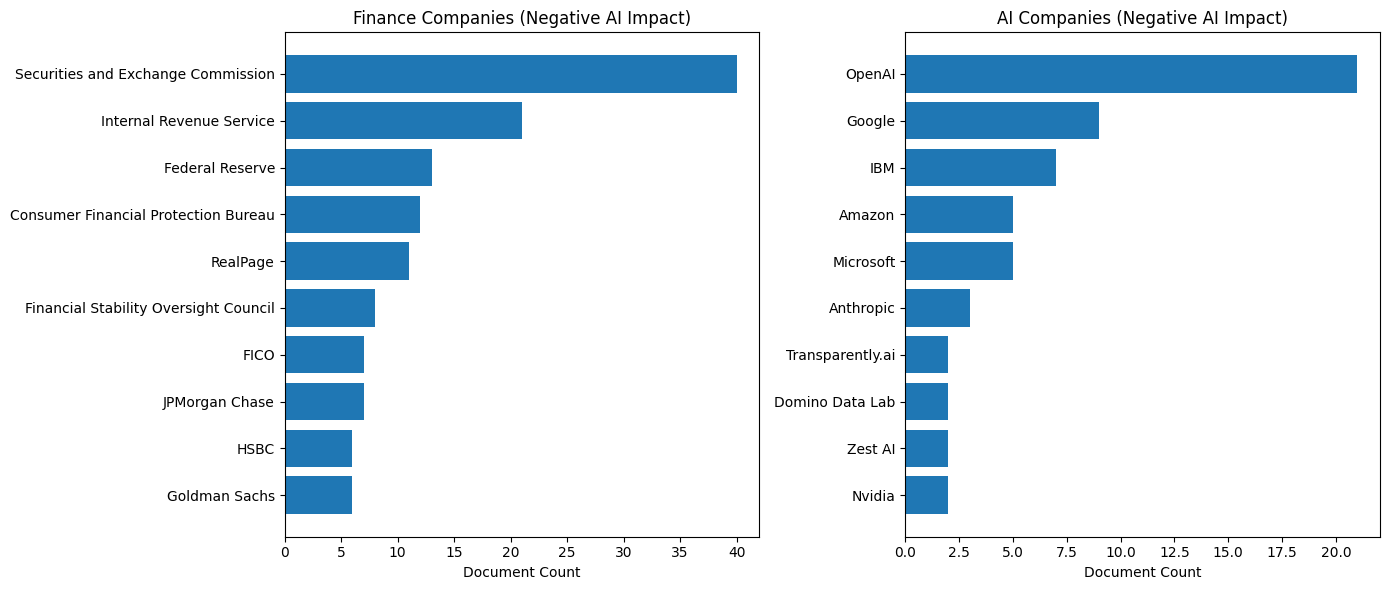

In [154]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [63]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(1120, 2)
(161, 2)


,entity_raw,raw_count
0,artificial intelligence,54
1,generative AI,42
2,AI,25
3,inaccurate decision-making,18
4,machine learning,17
...,...,...
156,AI Washing,2
157,AI applications,2
158,AI as a service,2
159,vendor lock-in,2


In [98]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (artificial intelligence, 54)\n- (generative AI, 42)\n- (AI, 25)\n- (inaccurate decision-making, 18)\n- (machine learning, 17)\n- (loss of trust, 14)\n- (ChatGPT, 12)\n- (job displacement, 12)\n- (privacy concerns, 12)\n- (AI models, 11)\n- (chatbots, 10)\n- (AI tools, 10)\n- (risk of using AI-generated content, 10)\n- (conflicts of interest, 9)\n- (predictive data analytics, 9)\n- (AI systems, 7)\n- (bias, 7)\n- (algorithms, 7)\n- (AI system learning from corrupted data, 6)\n- (workforce reduction, 6)\n- (bad AI predictions, 6)\n- (overreliance on AI, 6)\n- (large language models, 5)\n- (lack of transparency, 5)\n- (AI-driven algorithms, 5)\n- (algorithmic intermediary, 5)\n- (collusion, 5)\n- (artificial intelligence software, 5)\n- (rent-setting algorithms, 5)\n- (price-forecasting algorithm, 5)\n- (price-fixing, 5)\n- (AI software, 5)\n- (AI could not keep pace with rapid and unprecedented market swings, 5)\n- (inflated prices, 5)\n- (algorithm, 5)\n- (hallucinations, 4)\n- (lit

In [99]:
neg_mech_top_system_msg = """\
You are an AI technology and business mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from finance-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_business_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI business negative impact mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.
Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing

Examples of NEGATIVE impact mechanisms:
- job displacement
- workforce reduction
- layoffs
- risk of using AI-generated content
- privacy concerns
- data leakage
- implementation cost
- system failure
- inaccurate decision-making
- overreliance on AI
- litigation risk
- market manipulation risk
- loss of trust
- margin pressure

### other
Anything vague, unclear, or not clearly technology or mechanism.

Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.

Return valid JSON only.
"""

In [101]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [158]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,artificial intelligence,82,"[artificial intelligence, AI, artificial intel..."
1,generative AI,49,"[generative AI, Generative AI, generative arti..."
2,machine learning,20,"[machine learning, machine learning model]"
3,large language models,17,"[ChatGPT, large language models, ChatGPT chatbot]"
4,algorithms,17,"[algorithms, algorithm, AI-driven algorithms, ..."
5,predictive analytics,13,"[predictive data analytics, predictive analytics]"
6,AI models,11,[AI models]
7,chatbots,10,"[chatbots, chatbot, AI chatbots]"
8,AI tools,10,"[AI tools, AI tool]"
9,AI systems,7,[AI systems]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,inaccurate decision-making,24,"[inaccurate decision-making, bad AI prediction..."
1,job displacement,16,"[job displacement, workforce reduction, impact..."
2,privacy concerns,15,"[privacy concerns, data privacy concerns, priv..."
3,loss of trust,14,"[loss of trust, consumer distrust in AI protec..."
4,risk of using AI-generated content,12,"[risk of using AI-generated content, AI-genera..."
5,bias,12,"[bias, training data skewed along race or othe..."
6,overreliance on AI,6,[overreliance on AI]
7,litigation risk,4,[litigation risk]
8,market manipulation risk,4,"[market manipulation, market manipulation risk]"
9,system failure,3,[system failure]


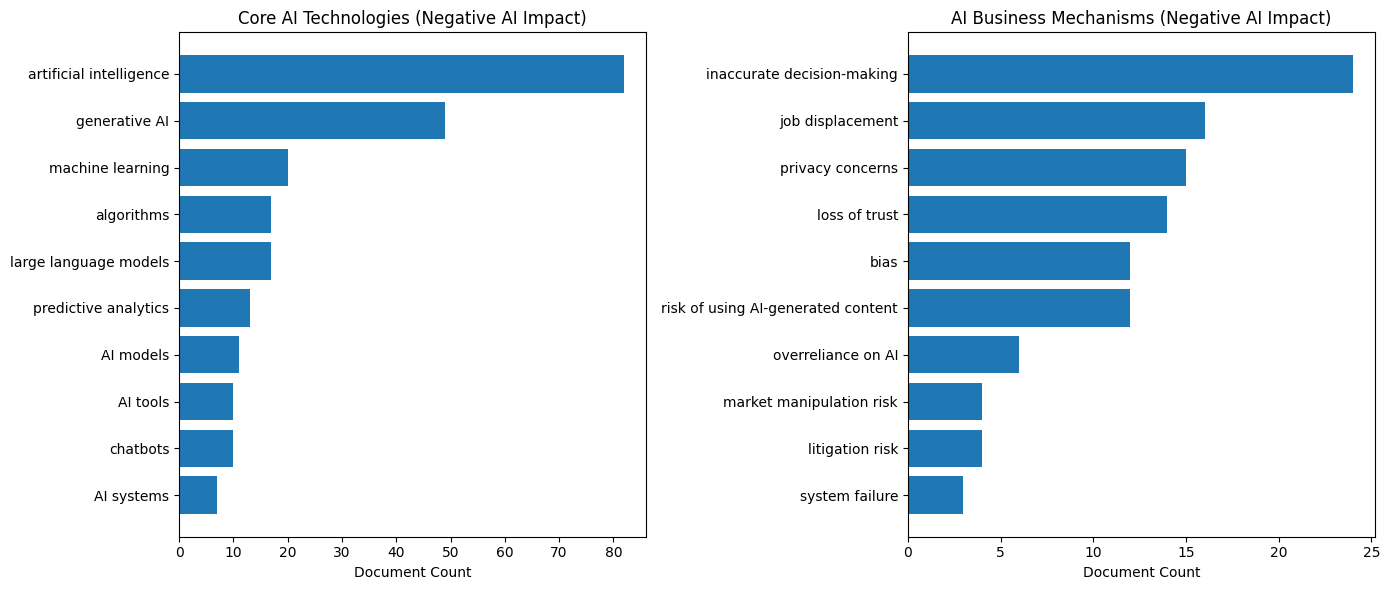

In [160]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [107]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/models/finance_ai_impact_classifier_v1_predictions.parquet")
df_ai_stock_pred  = pd.read_parquet(f"{DATA_DIR}/models/finance_ai_stock_classifier_predictions.parquet")

#### Topic Aggregation

In [108]:
Financial_topics = pd.read_csv(f"{DATA_DIR}/Industry_specific/Financial_topics.csv")
Financial_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Industry_specific/Financial_chunks_topics.parquet")

In [114]:
display(Financial_topics.head(2))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,824,-1_intelligence robotics_nasdaq artificial_tru...,"['intelligence robotics', 'nasdaq artificial',...",['First Trust Nasdaq Artificial Intelligence a...
1,0,5474,0_compliance_financial institutions_processes_...,"['compliance', 'financial institutions', 'proc...",['Opportunities\n\nAdvanced Portfolio Optimiza...


##### AI Impact

In [136]:
ai_impact_topic_id = [0,2,10]
ai_impact_topics = Financial_topics[Financial_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
1,0,"['compliance', 'financial institutions', 'proc...",['Opportunities\n\nAdvanced Portfolio Optimiza...
3,2,"['advisor', 'indicator', 'forex', 'automated',...",['(Note_SET FILE IS ATTACHED IN COMMENT)\nThe ...
11,10,"['insurers', 'underwriting', 'claim', 'life in...","[""Xceedance Partners with mea Platform to Adva..."


In [137]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in ai_impact_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

ai_impact_topics["topic_summary"] = summaries
show_full(ai_impact_topics[["Topic", "topic_summary"]])

,Topic,topic_summary
1,0,AI enhances compliance and lending processes in financial institutions.
3,2,This topic is about automated trading advisors (EAs) that use AI and logic to trade forex and other pairs.
11,10,"This topic is about how insurers are adopting AI to improve underwriting, claims processing, and operational efficiency."


In [119]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label_id,pred_label,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,49_0_0_0_0,https://www.wbay.com/prnewswire/2022/02/03/cus...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",2,positively,0.020864,0.075355,0.903781,49
1,50_0_0_0_0,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",0,"""From customer service to complex banking task...",2,positively,0.021277,0.069593,0.909130,50


In [131]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,0,80,203,2242
1,2,153,2,398
2,10,3,8,219


pred_label,topic,hard-to-say,negatively,positively
0,0,3.17%,8.04%,88.79%
1,2,27.67%,0.36%,71.97%
2,10,1.3%,3.48%,95.22%


In [134]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,0,0.031683,0.080396,0.887921,0.807525
1,2,0.276673,0.003617,0.719711,0.716094
2,10,0.013043,0.034783,0.952174,0.917391


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [135]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.90, 0.00, 0.10],
    [0.06, 0.24, 0.71],
    [0.02, 0.00, 0.98]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,0,0.132188,0.062744,0.805068,0.742324
1,2,1.000000,0.000000,0.000000,0.000000
2,10,0.054377,0.014348,0.931274,0.916926


Topic 1 collapses to hard-to-say

Because:

- It has moderate hard-to-say presence (27%).

- The confusion matrix says 71% of true hard-to-say gets predicted positive.

- Therefore the large predicted positive mass can be fully “explained” by hard-to-say leakage.

- The inversion essentially says:


“This topic is not truly positive — it is mostly ambiguous.”

#### Entity Aggregation

**This part has already been done in the NER Part.**

My current approach estimates:

$P(entity \mid sentiment)$

That is:

Given that a text expresses a certain sentiment (positive or negative AI impact), which entities appear most frequently?

This is a sentiment-conditioned entity frequency analysis.

It answers a framing question:In positive AI impact narratives, who and what are being discussed?

A common alternative estimates:

$P(sentiment \mid entity)$

That is:

Given that an entity appears, what is the sentiment distribution of the texts mentioning it?

In practice, it's: 
	1.	Collect all texts mentioning each entity.
	2.	Aggregate their sentiment labels.
	3.	Compute a sentiment score per entity.

This is an entity-conditioned sentiment analysis.

It answers an attribution question: Is this company typically discussed positively or negatively in AI contexts?

They are related through Bayes’ rule:

$$
P(entity \mid sentiment) =
\frac{P(sentiment \mid entity)\,P(entity)}{P(sentiment)}
$$

But they are not symmetric.

- $P(entity \mid sentiment)$ focuses on narrative composition.

- $P(sentiment \mid entity)$ focuses on reputational evaluation.

They answer different analytical questions.


Why My Approach Is More Suitable for This Project

The project aims to understand:

How AI impact discourse is constructed across positive and negative narratives.

In that context, $P(entity \mid sentiment)$ is more intuitive and aligned with your research goal because:

1. It directly reflects narrative framing. I am examining who and what appear in positive versus negative AI impact discussions.

2. It is structurally simpler given your data. My sentiment labels are assigned at the text level.

    Computing $P(sentiment \mid entity)$ would require:
        •	Aggregating texts per entity,
        •	Handling multi-entity texts,
        •	Addressing overlapping mentions,
        •	Managing small-sample instability.

3.	It avoids instability issues. Entity-level sentiment scores can become noisy for entities with few mentions.

4.	It preserves interpretability: “Top entities in positive AI narratives” is more straightforward to explain than per-entity sentiment attribution.

#### Time Aggregation

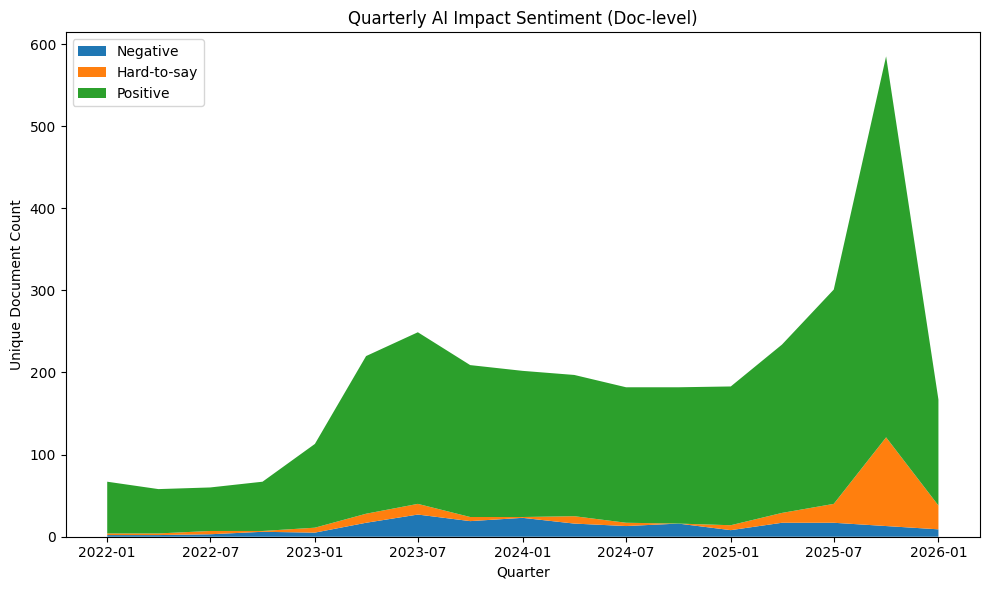

In [140]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

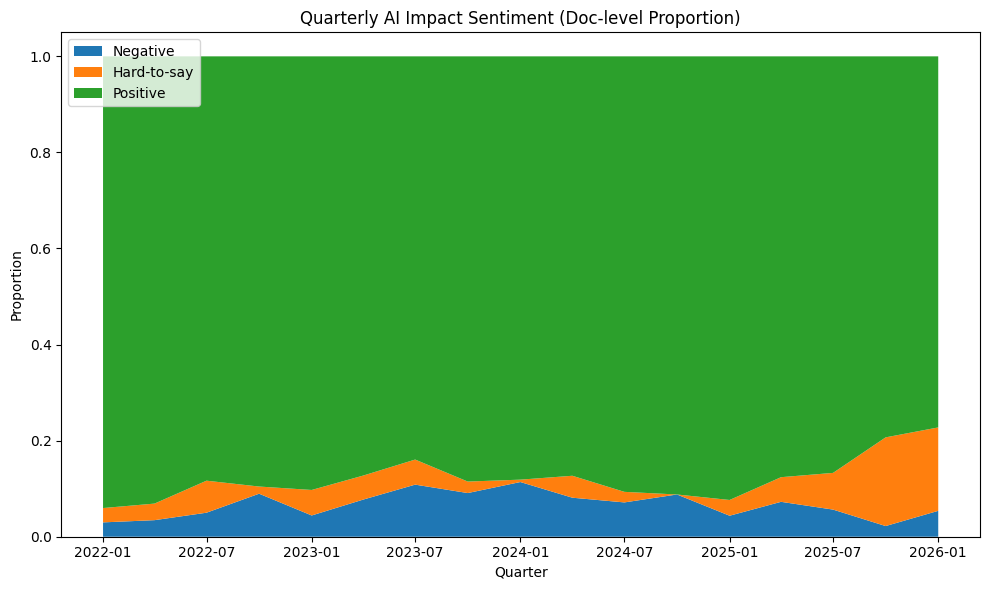

In [142]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

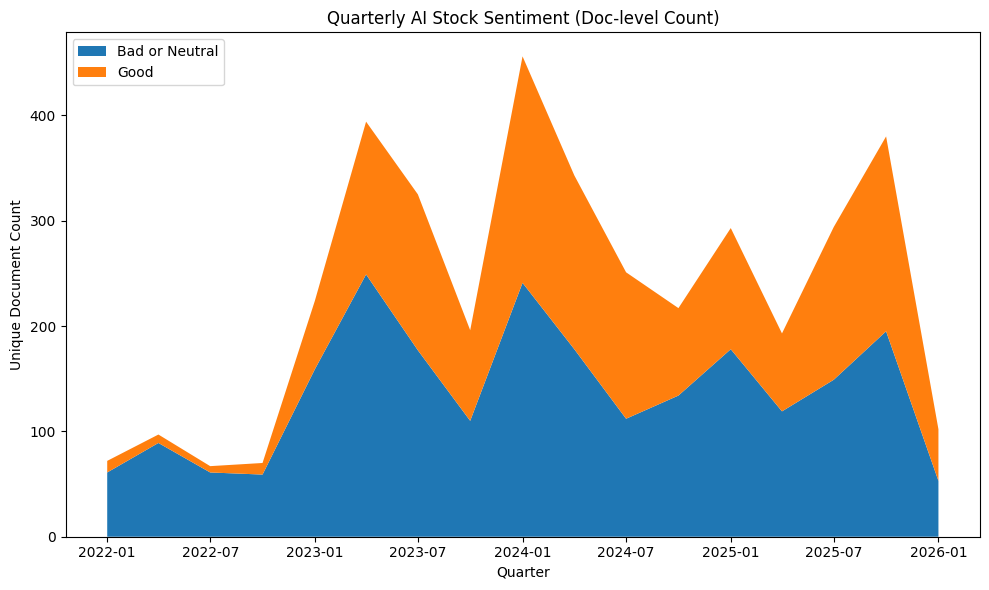

In [147]:
df_ai_stock_pred["doc_id"] = df_ai_stock_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_stock_pred["doc_id"] = df_ai_stock_pred["doc_id"].astype(int)
df_ai_stock_pred["date"] = pd.to_datetime(df_ai_stock_pred["date"])
df_ai_stock_pred["quarter"] = df_ai_stock_pred["date"].dt.to_period("Q")
stock_quarter_doc = (
    df_ai_stock_pred
    .groupby(["quarter", "pred_label"])["doc_id"]   
    .nunique()
    .rename("doc_count")
    .reset_index()
)
stock_quarter_pivot = (
    stock_quarter_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

stock_quarter_pivot.index = stock_quarter_pivot.index.to_timestamp()
plt.figure(figsize=(10,6))
plt.stackplot(
    stock_quarter_pivot.index,
    stock_quarter_pivot.get("bad-or-neutral", 0),
    stock_quarter_pivot.get("good", 0),
    labels=["Bad or Neutral", "Good"]
)
plt.legend(loc="upper left")
plt.title("Quarterly AI Stock Sentiment (Doc-level Count)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

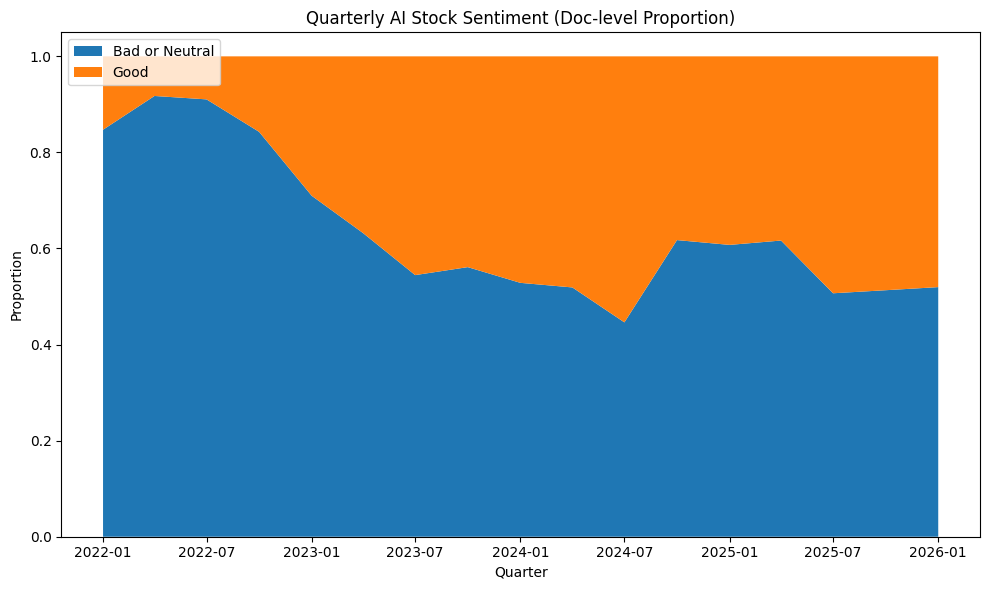

In [146]:
stock_quarter_prop = (
    stock_quarter_pivot
    .div(stock_quarter_pivot.sum(axis=1), axis=0)
)

plt.figure(figsize=(10,6))

plt.stackplot(
    stock_quarter_prop.index,
    stock_quarter_prop.get("bad-or-neutral", 0),
    stock_quarter_prop.get("good", 0),
    labels=["Bad or Neutral", "Good"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Stock Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()